---
authors: Freek Pols
updated: December 3, 2025
---

# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

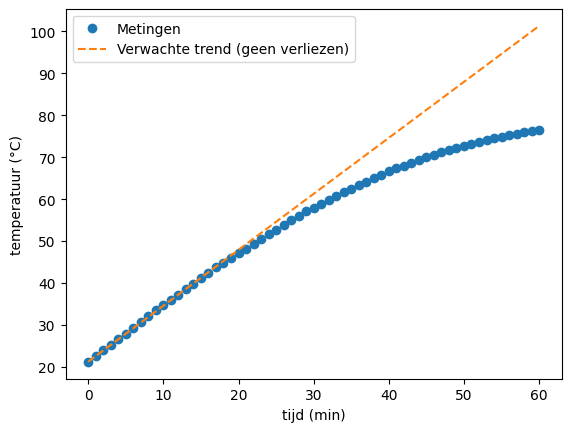

Lineaire fit beginfase:
dT/dt = 1.334 °C/min
T(0)  ≈ 21.25 °C

Energiebalans:
Massa water (start)  : 472.1 g
Massa verdampt       : 18.0 g
Temperatuurstijging  : 55.4 °C
Energie opwarming    : 1.09e+05 J
Energie verdamping   : 4.06e+04 J
Totaal toegevoegde Q : 1.50e+05 J

gemaakte aanames:
- specifieke warmtecapaciteit en latente warmte zijn constant
- homogeen mengsel
- gemiddelde temperatuurstijging van het water


In [22]:
# uitwerking vraag 1 en 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

t = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,
 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
 55, 56, 57, 58, 59, 60])      # tijd in minuten
T = np.array([21.2, 22.6, 24.0, 25.2, 26.6, 27.9, 29.3, 30.8, 32.2, 33.5, 34.7, 36.0, 37.2, 38.5, 39.8, 41.1,
 42.5, 43.9, 44.9, 46.0, 47.1, 48.2, 49.4, 50.5, 51.6, 52.7, 53.9, 55.0, 56.1, 57.1, 58.0, 58.9,
 59.9, 60.8, 61.6, 62.5, 63.4, 64.2, 65.0, 65.8, 66.6, 67.4, 68.0, 68.7, 69.3, 70.0, 70.6, 71.2,
 71.7, 72.2, 72.7, 73.2, 73.7, 74.1, 74.5, 74.9, 75.3, 75.6, 76.0, 76.2, 76.6])       # temperatuur in graden Celsius


# Lineaire fit op de beginfase (eerste 5 minuten)
mask = t <= 5
coeff = np.polyfit(t[mask], T[mask], 1)
trend = np.polyval(coeff, t)

# Plot van metingen en verwachte trendlijn
plt.figure()
plt.plot(t, T, "o", label="Metingen")
plt.plot(t, trend, "--", label="Verwachte trend (geen verliezen)")
plt.xlabel("tijd (min)")
plt.ylabel("temperatuur (°C)")
plt.legend()
plt.show()

print("Lineaire fit beginfase:")
print(f"dT/dt = {coeff[0]:.3f} °C/min")
print(f"T(0)  ≈ {coeff[1]:.2f} °C")

# Gegeven massa's (in gram)
m_maatbeker = 820.8
m_start = 1292.9
m_eind = 1274.9

m_water_start = m_start - m_maatbeker
m_water_eind = m_eind - m_maatbeker
m_verdamp = m_water_start - m_water_eind

# Constantes
c_water = 4.18     # in J/(g·K)
L_v = 2257         # in J/g (latente verdampingswarmte)

# Temperaturen
T_start = T[0]
T_eind = T[-1]
delta_T = T_eind - T_start

# Energieën
Q_opwarming = m_water_start * c_water * delta_T
Q_verdamping = m_verdamp * L_v
Q_totaal = Q_opwarming + Q_verdamping

print("\nEnergiebalans:")
print(f"Massa water (start)  : {m_water_start:.1f} g")
print(f"Massa verdampt       : {m_verdamp:.1f} g")
print(f"Temperatuurstijging  : {delta_T:.1f} °C")
print(f"Energie opwarming    : {Q_opwarming:.2e} J")
print(f"Energie verdamping   : {Q_verdamping:.2e} J")
print(f"Totaal toegevoegde Q : {Q_totaal:.2e} J")
print()
print("gemaakte aanames:\n- specifieke warmtecapaciteit en latente warmte zijn constant\n- homogeen mengsel\n- gemiddelde temperatuurstijging van het water")


## Aanbevelingen

Isoleer de maatbeker meer om zo het warmteverlies te beperken en bovenop doormiddel van iets van een dop met een klein gat voor de thermometer. En om meer nauwkeurige waarden te krijgen kan er geroerd worden in de maatbeker om zo minder verschillen van temperaturen in het water te hebben en er kan om de halve in plaats van de minuut worden gemeten voor meer meetwaarden en dus een preciezer uitkomst te krijgen